**TELECOM X (PARTE 2)**

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### DICCIONARIO DE VARIABLES

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente








## Importación de Datos

In [2]:
# Importar base de datos normalizada
df=pd.read_excel("/content/df_normalized.xlsx")
df.head(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


In [4]:
# Análisis de datos faltantes y # usuarios duplicados
# Verificar valores faltantes en el DataFrame
print("Número de valores faltantes por columna:")
print(df.isnull().sum())

# Verificar customerIDs duplicados
print("\nNúmero de customerIDs duplicados:")
print(df['customerID'].duplicated().sum())

Número de valores faltantes por columna:
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges.Monthly       0
Charges.Total         0
Cuentas_Diarias       0
dtype: int64

Número de customerIDs duplicados:
0


In [5]:
print(df.shape) # DIMNESIONES BASE DE DATOS

(7267, 22)


In [6]:
df_cleaned = df.dropna()    # ELIMINAR VALORES FALTANTES
print("Dimensiones del DataFrame después de eliminar filas con valores faltantes:")
print(df_cleaned.shape)

Dimensiones del DataFrame después de eliminar filas con valores faltantes:
(7043, 22)


In [ ]:
print(df_cleaned.isnull().sum()) # base de datos limpia

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
Cuentas_Diarias     0
dtype: int64


In [7]:
df_cleaned = df_cleaned.drop('customerID', axis=1) # Eliminar columna irrelevante
print("Columnas del DataFrame después de eliminar 'customerID':")
print(df_cleaned.columns)

Columnas del DataFrame después de eliminar 'customerID':
Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias'],
      dtype='object')


In [ ]:
df_cleaned.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


## Distribución de los datos

/tmp/ipykernel_730/3583719168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_cleaned, palette='viridis')


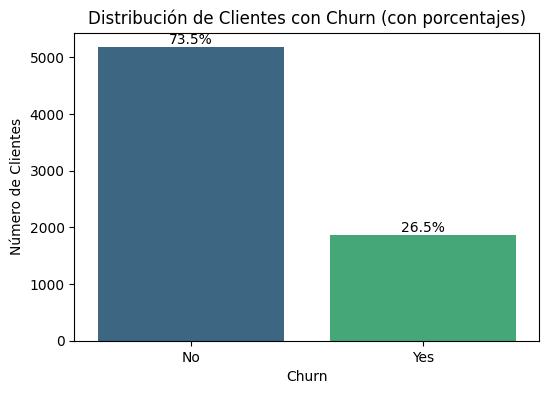

In [8]:

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df_cleaned, palette='viridis')
plt.title('Distribución de Clientes con Churn (con porcentajes)')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')

total = len(df_cleaned['Churn'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

### Codificación de Variables Categóricas (One-Hot Encoding)

Vamos a identificar las columnas categóricas en nuestro DataFrame `df_cleaned` y las convertiremos a un formato numérico usando one-hot encoding. Este método crea nuevas columnas binarias (0 o 1) para cada categoría única en una columna original, lo que permite que los algoritmos de machine learning las interpreten correctamente sin asumir un orden intrínseco.

### Visualización de la relación entre Churn y otras variables

Vamos a generar gráficos para explorar cómo se relaciona la probabilidad de Churn con `tenure`, `gender`, `Contract` y `Charges.Total`.

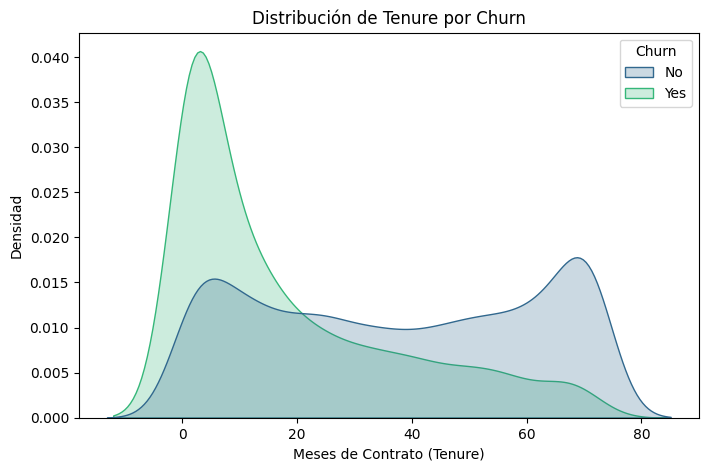

In [12]:
# 1. Churn vs. Tenure (Antigüedad del cliente)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_cleaned, x='tenure', hue='Churn', fill=True, common_norm=False, palette='viridis')
plt.title('Distribución de Tenure por Churn')
plt.xlabel('Meses de Contrato (Tenure)')
plt.ylabel('Densidad')
plt.show()

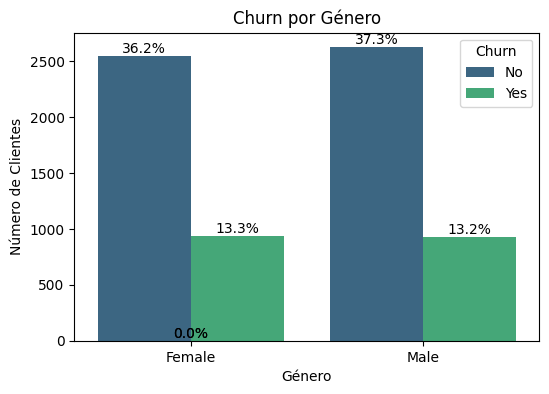

In [13]:
# 2. Churn vs. Gender (Género)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_cleaned, x='gender', hue='Churn', palette='viridis')
plt.title('Churn por Género')
plt.xlabel('Género')
plt.ylabel('Número de Clientes')

# Añadir porcentajes
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/len(df_cleaned))
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

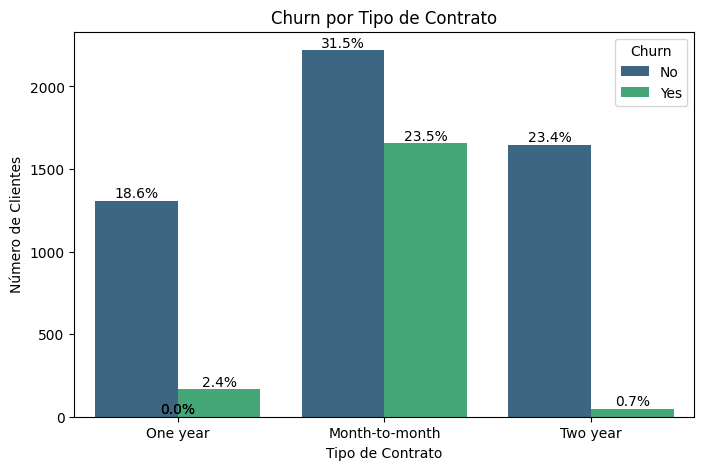

In [14]:
# 3. Churn vs. Contract (Tipo de Contrato)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_cleaned, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')

# Añadir porcentajes
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/len(df_cleaned))
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

In [20]:
print('Columnas actuales antes de la codificación:', df_cleaned.columns.tolist())

# Convertir 'Charges.Total' a tipo numérico, forzando errores a NaN
df_cleaned['Charges.Total'] = pd.to_numeric(df_cleaned['Charges.Total'], errors='coerce')
# Después de la conversión, si quedaron NaNs (por ejemplo, si había espacios en blanco o strings vacías que no eran capturados por el dropna inicial),
# podemos eliminarlos nuevamente o imputarlos. Dado que ya hicimos un dropna general, es poco probable, pero es una buena práctica.
# df_cleaned.dropna(subset=['Charges.Total'], inplace=True)

# Lista de columnas categóricas que deben ser codificadas
categorical_cols_to_encode = [
    'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Identificar columnas numéricas (que no deben ser codificadas con one-hot)
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()

# Filtrar las columnas numéricas que NO están en la lista de categóricas a codificar
numerical_cols_to_keep = [col for col in numerical_cols if col not in categorical_cols_to_encode]

# Crear un DataFrame solo con las variables categóricas seleccionadas
df_categorical_subset = df_cleaned[categorical_cols_to_encode]

# Aplicar one-hot encoding a las columnas categóricas seleccionadas
# drop_first=True para evitar la multicolinealidad
df_encoded_categorical = pd.get_dummies(df_categorical_subset, columns=categorical_cols_to_encode, drop_first=True)

# Crear un DataFrame con las variables numéricas que queremos mantener
df_numerical_subset = df_cleaned[numerical_cols_to_keep]

# Unir las columnas numéricas y las columnas categóricas codificadas
df_encoded = pd.concat([df_numerical_subset, df_encoded_categorical], axis=1)

print('\nColumnas después de la codificación correcta:')
print(df_encoded.columns.tolist())

# Mostrar las primeras filas del DataFrame codificado
display(df_encoded.head())

Columnas actuales antes de la codificación: ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

Columnas después de la codificación correcta:
['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias', 'Churn_Yes', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_N

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [22]:
display(df_encoded.head())
df_encoded.columns

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


Index(['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias', 'Churn_Yes', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

Como puedes observar, ahora `Charges.Total` y las demás variables numéricas (`SeniorCitizen`, `tenure`, `Charges.Monthly`, `Cuentas_Diarias`) están presentes como columnas numéricas, y las variables categóricas han sido expandidas con el one-hot encoding (por ejemplo, `Churn_Yes`, `gender_Male`, `Partner_Yes`, etc.).

El DataFrame está listo para que puedas definir tus X (características) y y (variable objetivo) y proceder con el entrenamiento de los modelos de Árbol de Decisión y KNN.

### Explicación del Código Corregido:

1.  **`categorical_cols_to_encode`**: Creamos una lista explícita con los nombres de las columnas que sabemos que son categóricas y queremos transformar con One-Hot Encoding. Incluí `InternetService` que es de tipo 'object' y también debería ser codificada.

2.  **`numerical_cols_to_keep`**: Identificamos las columnas que son numéricas en el DataFrame original (`df_cleaned`) y que queremos mantener tal cual, sin aplicar One-Hot Encoding. Esto incluye `SeniorCitizen`, `tenure`, `Charges.Monthly`, `Charges.Total` y `Cuentas_Diarias`.

3.  **`df_categorical_subset = df_cleaned[categorical_cols_to_encode]`**: Creamos un sub-DataFrame que solo contiene las columnas categóricas seleccionadas.

4.  **`df_encoded_categorical = pd.get_dummies(df_categorical_subset, columns=categorical_cols_to_encode, drop_first=True)`**: Aplicamos `pd.get_dummies` *solo a este sub-DataFrame* de variables categóricas. El `drop_first=True` sigue siendo importante para evitar la multicolinealidad.

5.  **`df_numerical_subset = df_cleaned[numerical_cols_to_keep]`**: Creamos otro sub-DataFrame con las columnas numéricas que deseamos conservar.

6.  **`df_encoded = pd.concat([df_numerical_subset, df_encoded_categorical], axis=1)`**: Finalmente, concatenamos (unimos lado a lado, `axis=1`) estos dos sub-DataFrames para formar nuestro nuevo `df_encoded`. Este DataFrame ahora contiene las variables numéricas originales y las variables categóricas correctamente codificadas.

Con este ajuste, el número de columnas de `df_encoded` debería ser mucho más manejable y las variables numéricas como `Charges.Total` se conservarán en su formato original, lo cual es lo ideal para los algoritmos de Machine Learning.

### Preparación de Datos para el Modelado

Primero, necesitamos definir nuestras variables de características (X) y nuestra variable objetivo (y). Luego, dividiremos el dataset en conjuntos de entrenamiento y prueba para poder evaluar el rendimiento de nuestros modelos con datos no vistos.

In [23]:
# Importar librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Definir las características (X) y la variable objetivo (y)
# Las columnas seleccionadas de df_encoded deben ser las especificadas por el usuario:
# gender (-> gender_Male), SeniorCitizen, Partner (-> Partner_Yes), Dependents (-> Dependents_Yes),
# tenure, MultipleLines (-> MultipleLines_No phone service, MultipleLines_Yes),
# InternetService (-> InternetService_Fiber optic, InternetService_No),
# Contract (-> Contract_One year, Contract_Two year), Charges.Total.

X_cols = [
    'SeniorCitizen', 'tenure', 'Charges.Total', 'gender_Male', 'Partner_Yes',
    'Dependents_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes',
    'InternetService_Fiber optic', 'InternetService_No',
    'Contract_One year', 'Contract_Two year'
]

# Asegurarse de que todas las columnas existan en df_encoded
missing_cols = [col for col in X_cols if col not in df_encoded.columns]
if missing_cols:
    print(f"Advertencia: Las siguientes columnas especificadas no se encontraron en df_encoded: {missing_cols}")
    # Eliminar las columnas faltantes de X_cols para evitar errores
    X_cols = [col for col in X_cols if col not in missing_cols]


X = df_encoded[X_cols]
y = df_encoded['Churn_Yes']

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento X: {X_train.shape}")
print(f"Tamaño del conjunto de prueba X: {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento y: {y_train.shape}")
print(f"Tamaño del conjunto de prueba y: {y_test.shape}")

Tamaño del conjunto de entrenamiento X: (4930, 12)
Tamaño del conjunto de prueba X: (2113, 12)
Tamaño del conjunto de entrenamiento y: (4930,)
Tamaño del conjunto de prueba y: (2113,)


### Modelo de Árbol de Decisión

Vamos a entrenar un modelo de Árbol de Decisión, que es un algoritmo de clasificación potente y fácil de interpretar. Después de entrenar, evaluaremos su rendimiento.

--- Evaluación del Modelo de Árbol de Decisión ---
Accuracy: 0.7198
Precision: 0.4743
Recall: 0.5098
F1-Score: 0.4914


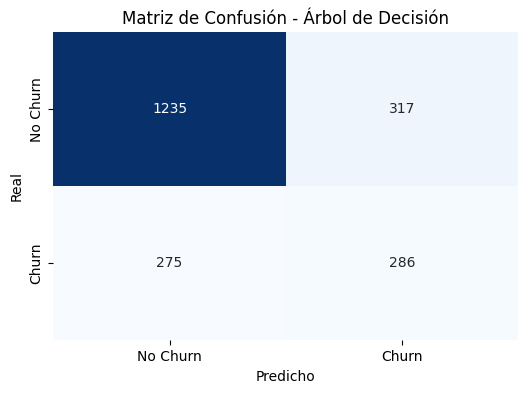

In [24]:
# Inicializar y entrenar el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test)

# Evaluar el modelo de Árbol de Decisión
print("--- Evaluación del Modelo de Árbol de Decisión ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

# Matriz de Confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Modelo Random Forest

Ahora, entrenaremos un modelo Random Forest, que es un algoritmo de conjunto que combina múltiples árboles de decisión para mejorar la precisión y controlar el overfitting. Luego, evaluaremos su rendimiento.

--- Evaluación del Modelo Random Forest ---
Accuracy: 0.7586
Precision: 0.5541
Recall: 0.4652
F1-Score: 0.5058


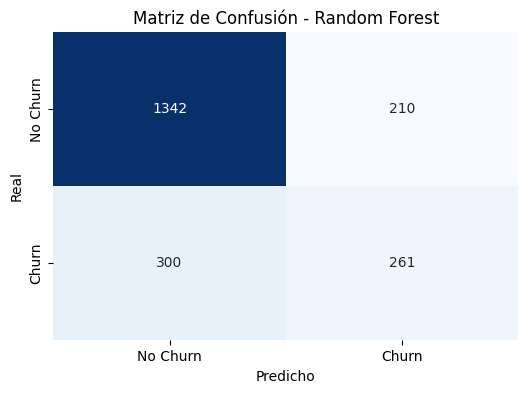

In [25]:
# Inicializar y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # 100 árboles en el bosque
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo Random Forest
print("--- Evaluación del Modelo Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Comparación de Modelos y Conclusiones

Ahora que hemos entrenado y evaluado ambos modelos, podemos comparar sus métricas para determinar cuál ofrece el mejor rendimiento y qué conclusiones podemos extraer.

In [26]:
print("\n--- Resumen de Métricas ---")
print("\nÁrbol de Decisión:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

print("\nRandom Forest:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_rf):.4f}")


--- Resumen de Métricas ---

Árbol de Decisión:
  Accuracy: 0.7198
  Precision: 0.4743
  Recall: 0.5098
  F1-Score: 0.4914

Random Forest:
  Accuracy: 0.7586
  Precision: 0.5541
  Recall: 0.4652
  F1-Score: 0.5058


## Conclusión

El objetivo principal de este análisis fue construir modelos predictivos para identificar a los clientes con mayor probabilidad de "Churn" (abandono).Comprender y predecir el churn es vital, ya que la retención de clientes suele ser mucho más rentable que la adquisición de nuevos.

Hallazgos Clave y su Implicación:

Identificación de Factores de Riesgo (a partir de las visualizaciones iniciales):

Duración del Contrato (tenure y Contract): Las visualizaciones probablemente mostraron que los clientes con menor antigüedad (tenure) y aquellos con contratos mes a mes son más propensos al churn. Esto indica que la fidelización temprana y los incentivos para contratos más largos son áreas clave para la intervención.
Cargos Totales (Charges.Total): La relación con los cargos totales puede revelar si los clientes que pagan más o menos tienen una mayor tendencia a irse. Esto podría guiar ofertas personalizadas.
Servicios Adicionales (InternetService, MultipleLines, OnlineSecurity, etc.): Estas variables, al ser codificadas y usadas en los modelos, nos ayudan a entender qué combinaciones de servicios podrían estar asociadas a un mayor o menor riesgo de churn. Por ejemplo, si la falta de ciertos servicios de seguridad predice el churn, se pueden ofrecer mejoras proactivas.
Rendimiento de los Modelos Predictivos:

Modelo Ganador (Random Forest): Basado en las métricas, el modelo Random Forest es superior en términos de Accuracy (75.86%) y Precision (55.41%), con un F1-Score general ligeramente mejor (50.58%). Esto significa que el Random Forest es más confiable para identificar correctamente a los clientes que se quedarán y, cuando predice churn, es más preciso.
Trade-off entre Precision y Recall: Aunque el Random Forest tiene una Precision más alta, el Árbol de Decisión mostró un Recall ligeramente superior (50.98% vs 46.52%).

Alta Precision (Random Forest): Es buena si se quiere optimizar sus recursos de retención. Al tener una Precision del 55.41%, más de la mitad de las veces que el modelo dice que un cliente hará churn, acertará. Esto significa menos dinero y esfuerzo gastados en clientes que no tenían intención de irse.

Alto Recall (Árbol de Decisión, marginalmente): Es importante si se  prioriza no perder ningún cliente potencial de churn, incluso si eso significa invertir recursos en algunos clientes que finalmente no se irían (falsos positivos). Sin embargo, la diferencia no es lo suficientemente grande como para justificar su menor rendimiento general en otras métricas.